In [37]:
from pathlib import Path
import pandas as pd
from mordred import Calculator, descriptors
from rdkit.Chem import PandasTools
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
from pygad import GA
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

In [38]:
file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
df = df.sample(frac = 0.5, random_state = 114514, ignore_index = True)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)

calc = Calculator(descriptors, ignore_3D = True)
df1 = calc.pandas(df["ROMol"])
df1 = df1.apply(pd.to_numeric, errors = "coerce")
df1 = df1.dropna(axis = 1, thresh = int(0.7 * len(df1)))
df1 = df1.fillna(0)

100%|██████████| 752/752 [00:07<00:00, 102.38it/s]


In [39]:
var_selector = VarianceThreshold(threshold = 0.01)
df1_var = var_selector.fit_transform(df1)
selected_columns = df1.columns[var_selector.get_support()]
df2 = pd.DataFrame(df1_var, columns = selected_columns)

corr = df2.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df2 = df2.drop(columns = to_drop)

Importances = RandomForestRegressor().fit(StandardScaler().fit_transform(df2.values), df["Td(°C)"]).feature_importances_
feature_importances = pd.Series(Importances, index = df2.columns)
feature_importances = feature_importances.sort_values(ascending = False)
df2 = df2[feature_importances.index].iloc[:, : 70]

In [40]:
x_all = df2.values
y_all = df["Td(°C)"]

feats = [
    'BCUTv-1l', 'BCUTi-1h', 'NdsN',
    'AATS1s', 'AATS4s', 'AATSC3s', 'ATSC2i',
    'ETA_epsilon_5', 'GATS3dv', 'GATS3s',
    'MDEC-33', 'MATS1se', 'NsNH2',
    'PEOE_VSA1', 'SIC1', 'SlogP_VSA10', 'SMR_VSA4'
]
feature_names = df2.columns.tolist()
feats_index = [feature_names.index(feat) for feat in feats]
initial_pop = np.random.randint(0, 2, size = (120, 70))
initial_pop[ : 90, feats_index] = 1

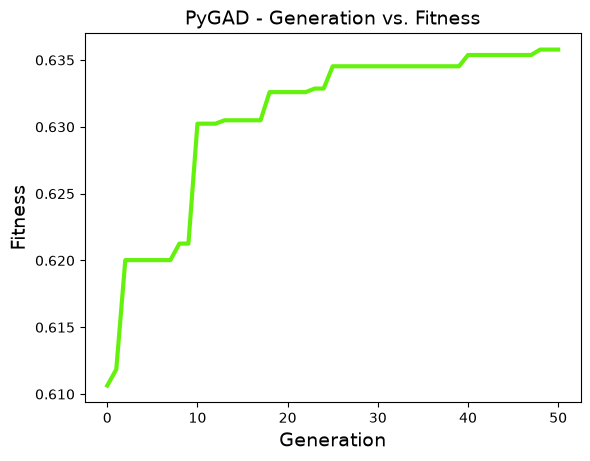

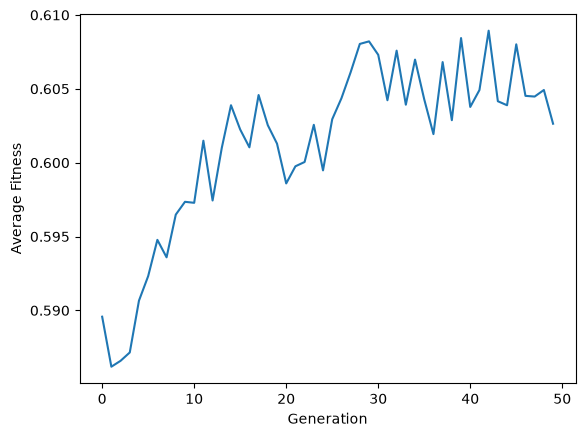

Index(['BCUTv-1l', 'AATSC3s', 'AATS1s', 'BCUTi-1h', 'NdsN', 'MIC1',
       'ETA_epsilon_5', 'ATSC3s', 'AATS1p', 'AATS5se', 'AATS5s', 'ATSC2i',
       'MDEC-33', 'PEOE_VSA3', 'ATSC4d', 'MATS1se', 'SlogP_VSA10', 'IC2',
       'AATSC0dv', 'AATS3se', 'GATS2p', 'SlogP_VSA2', 'MATS1s', 'AATS3p', 'nH',
       'piPC9', 'ATSC4v', 'SMR_VSA4'],
      dtype='str')

In [41]:
def fitness(ga_instance, solution, solution_idx):
    selected = np.where(solution == 1)[0]
    if len(selected) == 0:
        return -1e6
    rf = RandomForestRegressor(
        n_estimators = 80,
        max_depth = None,
        random_state = 322922
    )
    score = cross_validate(
        rf, x_all[:, selected], y_all,
        cv = KFold(n_splits = 5, shuffle = True),
        scoring = "r2",
        n_jobs = -1
    )
    return score["test_score"].mean() - len(selected) / 1500

avg_list = []
def on_gen(ga):
    fit = ga.last_generation_fitness
    if fit is not None:
        avg_list.append(np.mean(fit))

ga = GA(
    sol_per_pop = 120,
    num_genes = 70,
    gene_space = [0, 1],
    gene_type = int,
    initial_population = initial_pop,
    fitness_func = fitness,
    keep_elitism = 2,
    parent_selection_type = "tournament",
    K_tournament = 3,
    num_parents_mating = 10,
    crossover_type = "two_points",
    mutation_percent_genes = 3,
    num_generations = 50,
    on_generation = on_gen,
    parallel_processing = 8
)

ga.run()

ga.plot_fitness()
plt.plot(avg_list)
plt.xlabel("Generation")
plt.ylabel("Average Fitness")
plt.show()

best_solution = ga.best_solution()[0]
df3 = df2.iloc[:, np.where(best_solution == 1)[0]].columns
df3